In [1]:
import numpy as np
import matplotlib.ticker as ticker
import matplotlib.pyplot as plt
from ezyrb import POD, RBF, Database, Linear, RegularGrid
from ezyrb import ReducedOrderModel as ROM
from scipy.interpolate import griddata
from smooth_POD_ROM.pre_processing import (
    on_regular_grid, _gauss_2d, to_frequency, to_space, add_padding, smoothen, remove_wall, threshold)
from smooth_POD_ROM.post_processing import sharpen
from smooth_POD_ROM.io import get_data, get_field
from smooth_POD_ROM.plotting import plot_mesh, plot_field, plot_structured_field
from copy import deepcopy
from scipy.ndimage import gaussian_filter
from scipy.fft import fft2, ifft2, fftshift, ifftshift
from scipy.signal import wiener, convolve2d
from skimage import restoration
from skimage.restoration import richardson_lucy
import tvtk
import cv2
from datetime import datetime
from os import listdir
from os.path import isfile, join
import re

In [32]:
fine = False

In [33]:
mypath = "C:/Users/florianma/OneDrive - Institutt for Energiteknikk" + \
        "/Documents/data/damBreak_results/"
if fine:
    mypath = "//files.ad.ife.no/MatPro_files/Florian/damBreak_results_Finemesh/"
else:
    mypath = "//files.ad.ife.no/MatPro_files/Florian/damBreak_results/"
        
rank = 80
size_p_test = 1
timestep = 0.02

In [34]:
def get_data(pth, nu_all, rho_all, timesteps=np.linspace(0.01, 1, 100)):
    if len(nu_all) == 0:
        return np.empty((100, 0)), np.empty((0, 2)), np.empty((0, 0))
    X = []
    params = []
    for n, r in zip(nu_all, rho_all):
        for ts in timesteps:
            if fine:
                file = "res_m{:04.4f}_r{:04.4f}_t{:.2f}/internal.vtu".format(n, r, ts)
            else:
                file = "damBreak_m{:02.1f}_r{:02.1f}_t{:.2f}/internal.vtu".format(n, r, ts)
            data = get_field(pth+file, 'alpha.water')
            X.append(data)
            params.append([n, r, ts])
    if len(timesteps) == 1:
        params = np.array(params)[:, :2]
    snapshots3D = np.array(X).T
    
    points3D = get_field(pth+file, 'points')
    forbidden_points = points3D[:, 2] > 0.0
    snapshots = snapshots3D[~forbidden_points, :]
    points = points3D[~forbidden_points, :2]
    return snapshots, params, points

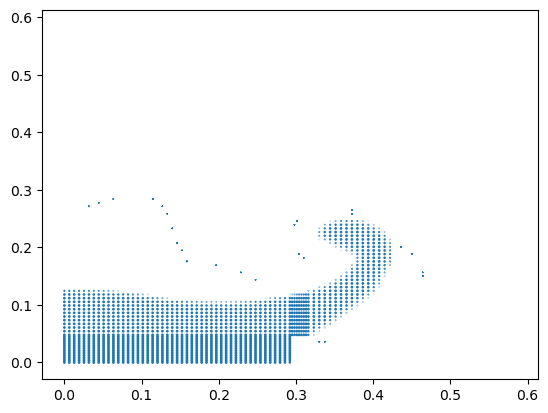

In [35]:
u_train, p_train, points = get_data(mypath, [10], [10], timesteps=[0.3])
#plt.plot(points[:, 0], points[:, 1], "k,")
plt.scatter(points[:, 0], points[:, 1], u_train[:, 0])